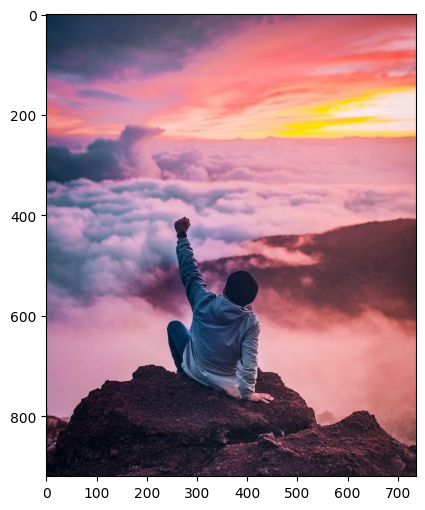

In [2]:
import matplotlib.pyplot as plt
from PIL import Image
import requests

url="https://i.pinimg.com/736x/60/a6/e2/60a6e2b0776d1d6735fce5ae7dc9b175.jpg"
image = Image.open(requests.get(url, stream=True).raw)
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.show()

In [8]:
import numpy as np
img_np=np.array(image)
print(img_np.shape)
print(img_np.dtype)

(920, 736, 3)
uint8


(700, 600, 3)


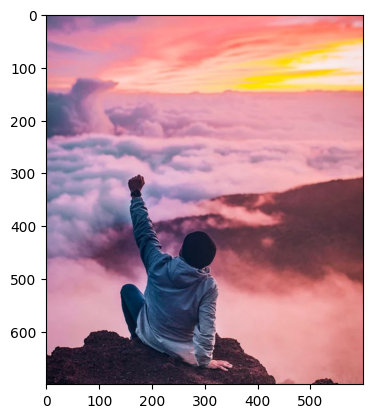

In [14]:
#let's slice it first
img_sliced=img_np[100:800,100:700,]
print(img_sliced.shape)
#img_sliced
plt.imshow(img_sliced)


In [17]:
# now let's inspect colour channel
print(img_sliced[:,:,0])
print(img_sliced[:,:,1])
print(img_sliced[:,:,2])

[[ 93  94  95 ... 231 231 230]
 [ 93  94  95 ... 232 231 231]
 [ 93  93  95 ... 233 232 232]
 ...
 [ 29  31  29 ... 201 200 199]
 [ 26  27  27 ... 199 199 198]
 [ 17  17  18 ... 197 197 196]]
[[ 89  90  89 ... 115 115 116]
 [ 89  90  89 ... 116 117 117]
 [ 89  89  89 ... 117 117 117]
 ...
 [ 21  23  23 ... 116 115 114]
 [ 15  19  21 ... 114 114 113]
 [  9  11  12 ... 114 112 113]]
[[126 127 127 ... 116 116 116]
 [126 127 127 ... 117 117 117]
 [126 126 127 ... 120 120 120]
 ...
 [ 34  36  35 ... 113 112 111]
 [ 29  32  33 ... 111 111 110]
 [ 22  23  24 ... 110 109 109]]


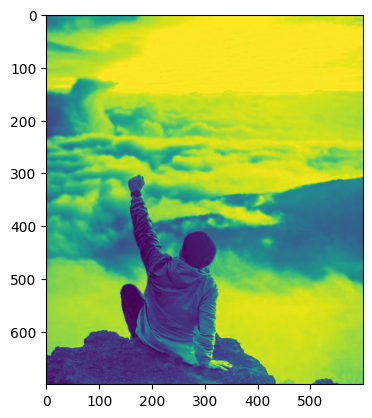

In [19]:
#let's view this in picture format
plt.imshow(img_sliced[:,:,0])

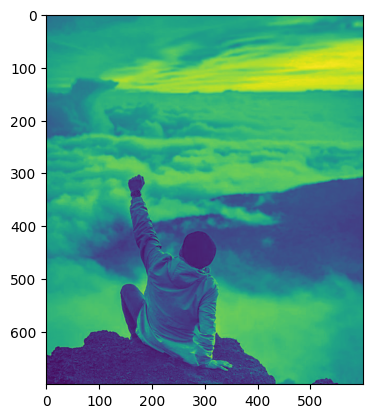

In [20]:
plt.imshow(img_sliced[:,:,1])

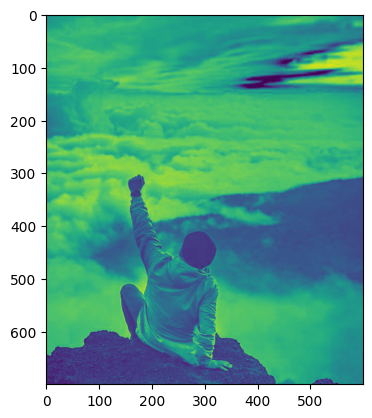

In [21]:
plt.imshow(img_sliced[:,:,2])

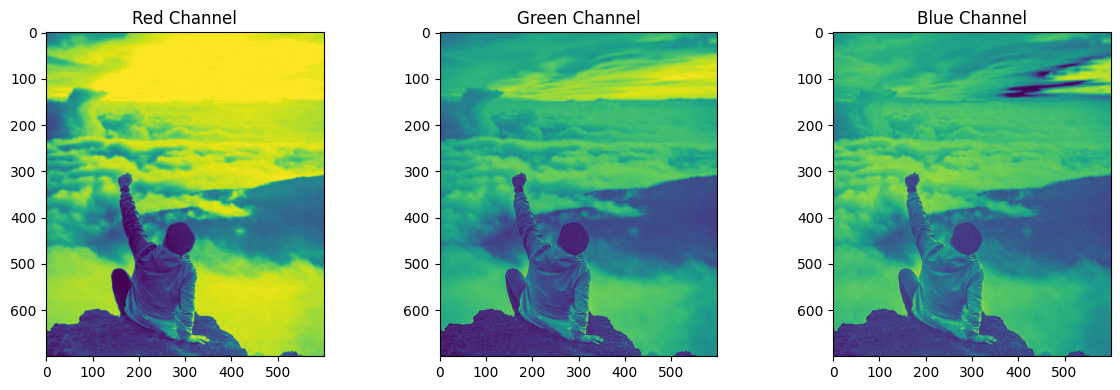

In [26]:
# here goes some ai-code
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Plot Red Channel
axes[0].imshow(img_sliced[:, :, 0])
axes[0].set_title("Red Channel")

# Plot Green Channel
axes[1].imshow(img_sliced[:, :, 1])
axes[1].set_title("Green Channel")

# Plot Blue Channel
axes[2].imshow(img_sliced[:, :, 2])
axes[2].set_title("Blue Channel")

plt.tight_layout()
plt.show()

In [29]:
import torch
img_tensor=torch.tensor(img_sliced)
print(img_tensor.shape)
# succesfully created maannnnnnnnnnnnn
#so basically dimension in numpy is H W C,now according to torch standard
# we will change that to C H  W


img_tensor=img_tensor.permute(2,0,1)
print(img_tensor)

torch.Size([700, 600, 3])
tensor([[[ 93,  94,  95,  ..., 231, 231, 230],
         [ 93,  94,  95,  ..., 232, 231, 231],
         [ 93,  93,  95,  ..., 233, 232, 232],
         ...,
         [ 29,  31,  29,  ..., 201, 200, 199],
         [ 26,  27,  27,  ..., 199, 199, 198],
         [ 17,  17,  18,  ..., 197, 197, 196]],

        [[ 89,  90,  89,  ..., 115, 115, 116],
         [ 89,  90,  89,  ..., 116, 117, 117],
         [ 89,  89,  89,  ..., 117, 117, 117],
         ...,
         [ 21,  23,  23,  ..., 116, 115, 114],
         [ 15,  19,  21,  ..., 114, 114, 113],
         [  9,  11,  12,  ..., 114, 112, 113]],

        [[126, 127, 127,  ..., 116, 116, 116],
         [126, 127, 127,  ..., 117, 117, 117],
         [126, 126, 127,  ..., 120, 120, 120],
         ...,
         [ 34,  36,  35,  ..., 113, 112, 111],
         [ 29,  32,  33,  ..., 111, 111, 110],
         [ 22,  23,  24,  ..., 110, 109, 109]]], dtype=torch.uint8)


In [38]:
# now we ahve to normalise every value
img_tensor=img_tensor.float()
img_tensor = torch.from_numpy(img_sliced).permute(2, 0, 1).float() / 255.0
img_tensor
#now add a batch dimenson b*c*h*w
img_tensor.unsqueeze(0)


tensor([[[[0.3647, 0.3686, 0.3725,  ..., 0.9059, 0.9059, 0.9020],
          [0.3647, 0.3686, 0.3725,  ..., 0.9098, 0.9059, 0.9059],
          [0.3647, 0.3647, 0.3725,  ..., 0.9137, 0.9098, 0.9098],
          ...,
          [0.1137, 0.1216, 0.1137,  ..., 0.7882, 0.7843, 0.7804],
          [0.1020, 0.1059, 0.1059,  ..., 0.7804, 0.7804, 0.7765],
          [0.0667, 0.0667, 0.0706,  ..., 0.7725, 0.7725, 0.7686]],

         [[0.3490, 0.3529, 0.3490,  ..., 0.4510, 0.4510, 0.4549],
          [0.3490, 0.3529, 0.3490,  ..., 0.4549, 0.4588, 0.4588],
          [0.3490, 0.3490, 0.3490,  ..., 0.4588, 0.4588, 0.4588],
          ...,
          [0.0824, 0.0902, 0.0902,  ..., 0.4549, 0.4510, 0.4471],
          [0.0588, 0.0745, 0.0824,  ..., 0.4471, 0.4471, 0.4431],
          [0.0353, 0.0431, 0.0471,  ..., 0.4471, 0.4392, 0.4431]],

         [[0.4941, 0.4980, 0.4980,  ..., 0.4549, 0.4549, 0.4549],
          [0.4941, 0.4980, 0.4980,  ..., 0.4588, 0.4588, 0.4588],
          [0.4941, 0.4941, 0.4980,  ..., 0

In [39]:
# let's ansayse
print(img_tensor.shape)
print(img_tensor.dtype)
print(img_tensor.min())
print(img_tensor.max())

torch.Size([3, 700, 600])
torch.float32
tensor(0.)
tensor(1.)


In [40]:
img_batch = img_tensor.unsqueeze(0)

print("Batch Tensor Shape:", img_batch.shape)
print("Data Type:", img_batch.dtype)
print("Min Value:", img_batch.min().item())
print("Max Value:", img_batch.max().item())

Batch Tensor Shape: torch.Size([1, 3, 700, 600])
Data Type: torch.float32
Min Value: 0.0
Max Value: 1.0
